<a href="https://colab.research.google.com/github/Alireza-hakimi/Explainable-AI-model-implementation/blob/main/model3_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv("Credit_Card_Fraud_Detection.csv")

df = df.drop(columns=["Unnamed: 0"])

df = df.rename(columns={"class": "Class"})

print("=" * 50)
print(f"Dataset Shape     : {df.shape}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")
print("\nClass Distribution:")
print(df["Class"].value_counts())
print(f"\nFraud Rate        : {df['Class'].mean() * 100:.2f}%")
print("=" * 50)
df.head()

Dataset Shape     : (690, 16)
Missing Values    : 0
Duplicate Rows    : 0

Class Distribution:
Class
0    383
1    307
Name: count, dtype: int64

Fraud Rate        : 44.49%


,Customer_ID,A_1,A_2,A_3,A_4,A_5,A_6,A_7,A_8,A_9,A_10,A_11,A_12,A_13,A_14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


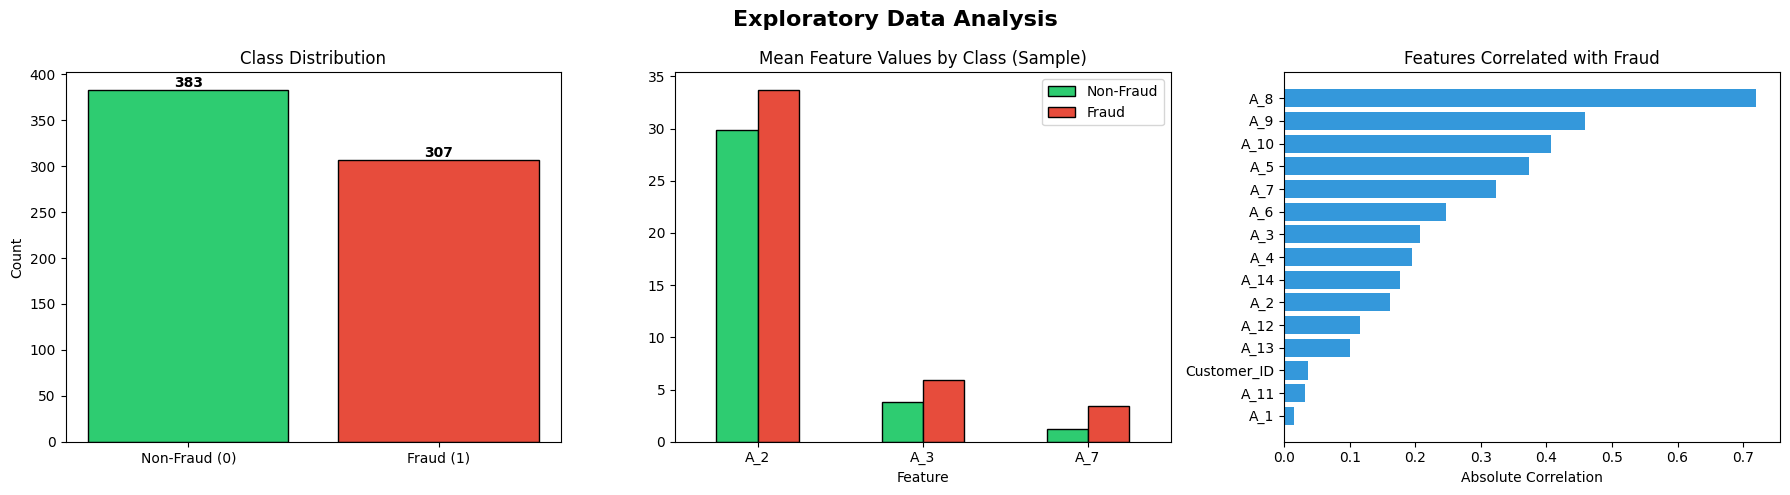

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold")

# Class distribution
axes[0].bar(["Non-Fraud (0)", "Fraud (1)"],
            df["Class"].value_counts().values,
            color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(df["Class"].value_counts().values):
    axes[0].text(i, v + 3, f"{v:,}", ha="center", fontweight="bold")

# Feature distributions by class
df.groupby("Class")[["A_2", "A_3", "A_7"]].mean().T.plot(
    kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[1].set_title("Mean Feature Values by Class (Sample)")
axes[1].set_xlabel("Feature")
axes[1].set_xticklabels(["A_2", "A_3", "A_7"], rotation=0)
axes[1].legend(["Non-Fraud", "Fraud"])

# Correlation with Class
corr = df.corr()["Class"].drop("Class").abs().sort_values(ascending=False)
axes[2].barh(corr.index[::-1], corr.values[::-1], color="#3498db")
axes[2].set_title("Features Correlated with Fraud")
axes[2].set_xlabel("Absolute Correlation")

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=["Customer_ID", "Class"])
y = df["Class"]

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 70% Train | 15% Val | 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size      : {X_train.shape[0]}")
print(f"Validation size : {X_val.shape[0]}")
print(f"Test size       : {X_test.shape[0]}")

Train size      : 483
Validation size : 103
Test size       : 104


In [ ]:
model = xgb.XGBClassifier(
    n_estimators          = 300,
    max_depth             = 4,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = "auc",
    early_stopping_rounds = 20,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")
print("Model training complete!")

[0]	validation_0-auc:0.90313
[50]	validation_0-auc:0.94699
[72]	validation_0-auc:0.94775

Best iteration: 52
Model training complete!


In [ ]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"AUC-ROC Score : {auc:.4f}")
print(f"F1 Score      : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))

TEST SET RESULTS
AUC-ROC Score : 0.9479
F1 Score      : 0.8542

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.91      0.84      0.88        58
       Fraud       0.82      0.89      0.85        46

    accuracy                           0.87       104
   macro avg       0.86      0.87      0.86       104
weighted avg       0.87      0.87      0.87       104



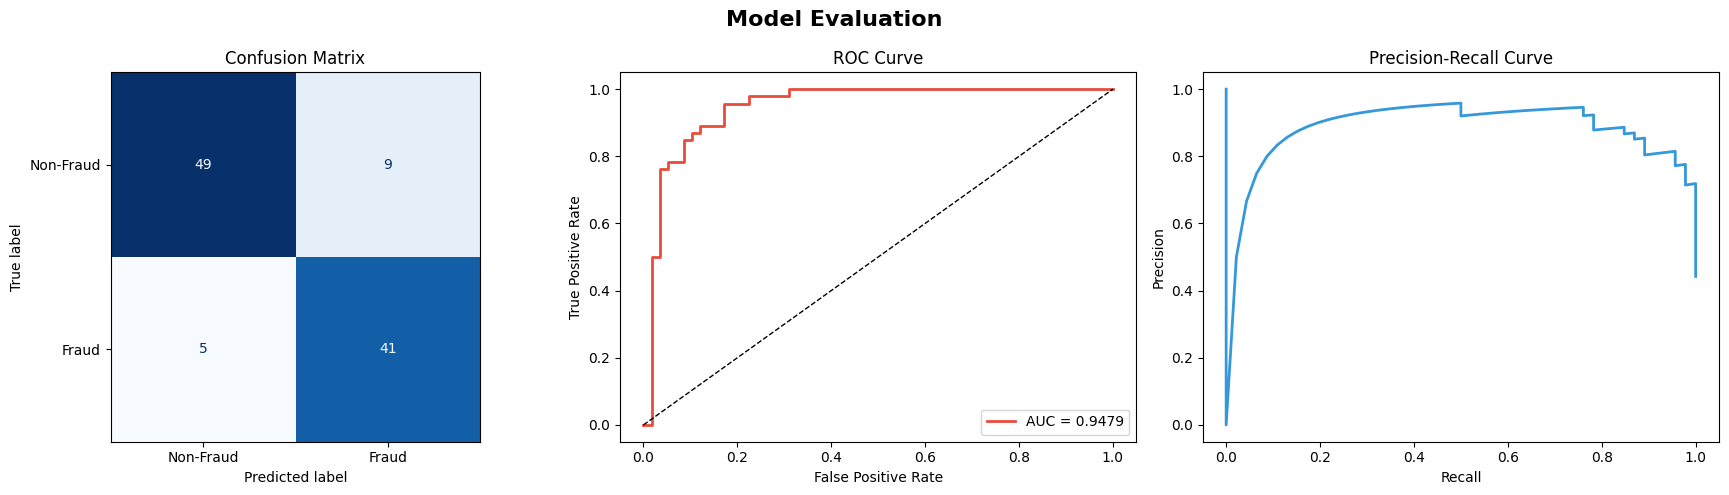

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation", fontsize=16, fontweight="bold")

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Non-Fraud", "Fraud"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, color="#3498db", lw=2)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

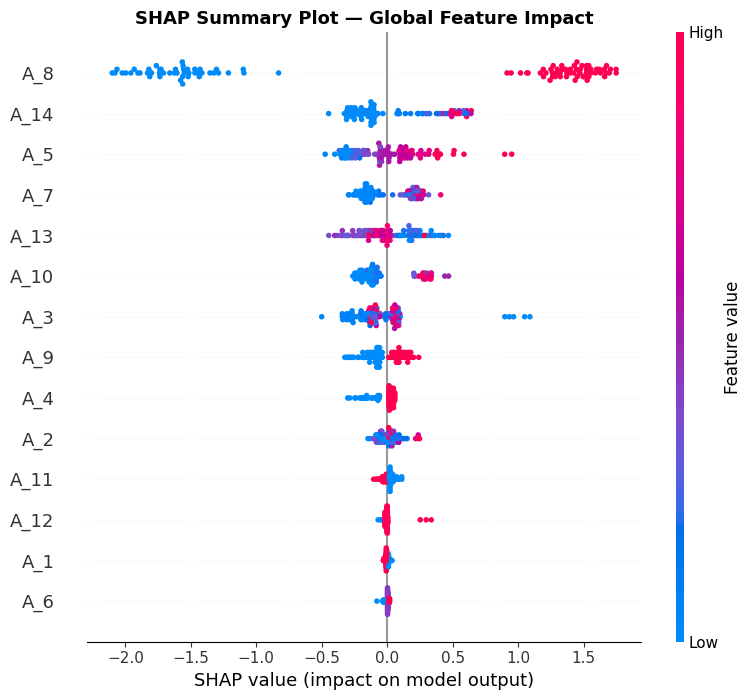

In [ ]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Summary Plot — Global Feature Impact", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Global Model Interpretability: SHAP Summary Plot (Beeswarm)

A **SHAP Beeswarm Summary Plot** was generated across the full test set to evaluate the global behavior of the XGBoost classifier on the Credit Card Fraud Detection dataset. Each point represents a single transaction, positioned by its SHAP value on the x-axis, with color indicating the original feature value **red** for high, **blue** for low.

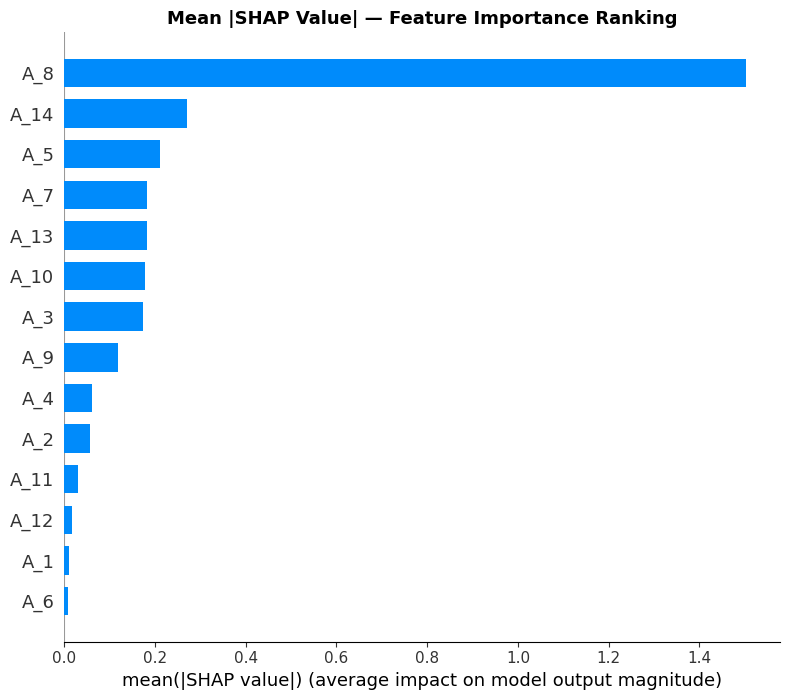

In [ ]:
# Bar chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Mean |SHAP Value| — Feature Importance Ranking", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Paste into a Text cell:

### Global Feature Importance: Mean SHAP Value Bar Chart

The **Mean Absolute SHAP Value Bar Chart** quantifies each feature's average impact magnitude across all test transactions, providing a clean and rankable importance score independent of direction.

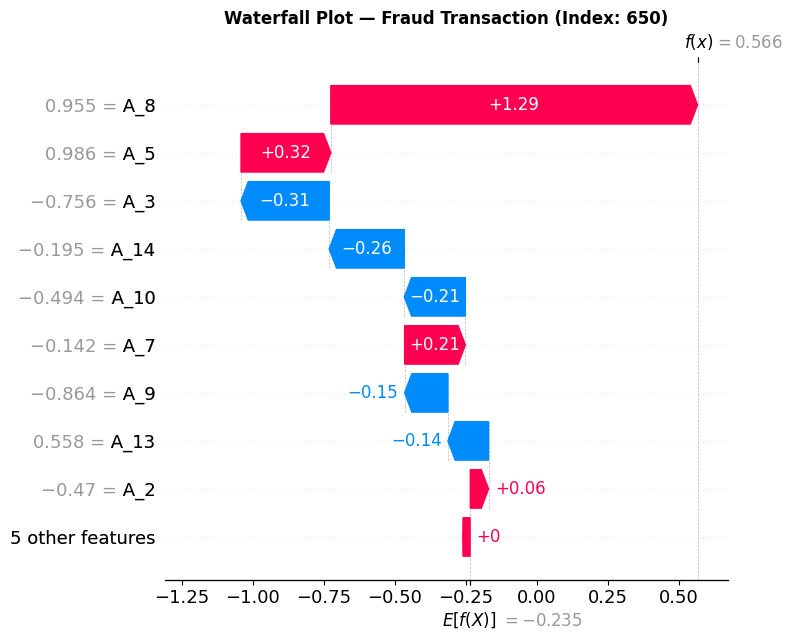

In [ ]:
# Fraud case
fraud_idx  = y_test[y_test == 1].index[0]
pos_fraud  = X_test.index.get_loc(fraud_idx)

shap.plots.waterfall(shap.Explanation(
    values        = shap_values[pos_fraud],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[pos_fraud],
    feature_names = X_test.columns.tolist()
), show=False)
plt.title(f"Waterfall Plot — Fraud Transaction (Index: {fraud_idx})", fontweight="bold")
plt.tight_layout()
plt.show()

### Local Model Interpretability: Waterfall Plot — Fraud Transaction
A **SHAP Waterfall Plot** was generated for a confirmed fraud case. Starting from the model's baseline of **E[f(x)] = −0.235**, each bar shows how individual features shift the prediction, arriving at a final score of **f(x) = 0.566** crossing the fraud threshold.

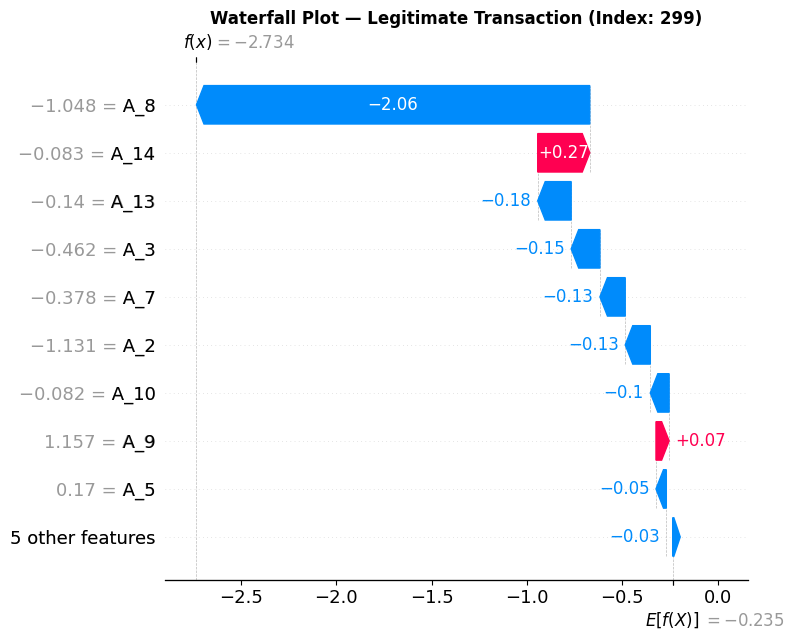

In [ ]:
# Legitimate case
legit_idx  = y_test[y_test == 0].index[0]
pos_legit  = X_test.index.get_loc(legit_idx)

shap.plots.waterfall(shap.Explanation(
    values        = shap_values[pos_legit],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[pos_legit],
    feature_names = X_test.columns.tolist()
), show=False)
plt.title(f"Waterfall Plot — Legitimate Transaction (Index: {legit_idx})", fontweight="bold")
plt.tight_layout()
plt.show()

### Local Model Interpretability: Waterfall Plot — Legitimate Transaction

A **SHAP Waterfall Plot** was generated for a confirmed legitimate transaction (Index: 299). Starting from the same baseline of **E[f(x)] = −0.235**, the model arrives at a final score of **f(x) = −2.734** deep in non-fraud territory.

In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[pos_fraud],
    X_test.iloc[pos_fraud],
    feature_names=X_test.columns.tolist()
)

### Local Model Interpretability: Force Plot — Fraud Transaction

As a final local explanation, a **SHAP Force Plot** was generated for the confirmed fraud transaction, presenting the same decision logic as the waterfall plot in a compact horizontal format.

## Conclusion

This study applied a **SHAP-based Explainable AI (XAI)** framework to an XGBoost fraud detection model trained on the Credit Card Fraud Detection dataset of 690 customer transactions. The analysis was conducted across global and local interpretability levels, revealing clear and consistent patterns in how the model identifies fraudulent behavior.

### What the XAI Analysis Concluded

At the global level, the SHAP analysis identified A_8 as the overwhelmingly dominant fraud indicator, contributing a mean SHAP of ~1.5 more than three times the impact of any other feature. The Beeswarm plot further confirmed that A_8 operates bidirectionally: high values push strongly toward fraud while low values push strongly toward legitimacy. A_14 and A_5 formed a meaningful but distant second tier, while the remaining features contributed progressively diminishing supporting signals.

At the local level, the Waterfall plots validated this behavior on individual transactions with striking consistency. In the fraud case, A_8 alone contributed +1.29 to the fraud score, crossing the classification threshold despite several features actively resisting the fraud verdict. In the legitimate case, the same A_8 feature contributed −2.06, driving the prediction deep into non-fraud territory with high confidence. This directional flip across both cases confirms that the model has learned a robust, context-sensitive decision boundary anchored almost entirely around A_8's behavior.